# Satellite Image Land Use Classification using CNN and PyTorch

## Project Overview

This project uses a Convolutional Neural Network (CNN) built with PyTorch to classify satellite images from the EuroSAT dataset into 10 different land use categories.

The workflow includes:

- Loading and preprocessing satellite images
- Building a CNN model
- Training the model using GPU acceleration
- Evaluating model performance
- Visualizing predictions and confusion matrix
- Saving the trained model

## GPU Setup

This section checks whether GPU acceleration is available for training the deep learning model.

In [1]:
# Check GPU
import torch

print("PyTorch version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
GPU Available: True
GPU: Tesla T4


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## EuroSAT Dataset

The EuroSAT dataset contains 27,000 satellite images categorized into 10 different land use and land cover classes.

Examples of classes include:

- Forest
- River
- Residential
- Highway
- Industrial
- SeaLake

The dataset is commonly used for remote sensing and satellite image classification tasks.

## Dataset Loading and Preprocessing

The EuroSAT dataset is loaded and transformed before training.

Preprocessing steps include:

- Resizing images to 64x64
- Converting images to tensors
- Normalizing pixel values

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_dir = "./data"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.EuroSAT(
    root=data_dir,
    download=True,
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

100%|██████████| 94.3M/94.3M [00:00<00:00, 349MB/s]


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Train-Test Split and Data Loaders

The dataset is divided into training and testing sets.

PyTorch DataLoaders are used for batching and efficient data loading during training.

In [4]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
torch.manual_seed(42)
train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("Train images:", len(train_data))
print("Test images:", len(test_data))
print("Batches in train_loader:", len(train_loader))
print("Batches in test_loader:", len(test_loader))

Train images: 21600
Test images: 5400
Batches in train_loader: 338
Batches in test_loader: 85


## CNN Model Architecture

A Convolutional Neural Network (CNN) is built for satellite image classification.

The architecture contains:

- 3 convolutional layers
- ReLU activation
- Max pooling layers
- Dropout regularization
- Fully connected layers for classification

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 -> 16
        x = self.pool(F.relu(self.conv3(x)))  # 16 -> 8

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model = CNNModel(num_classes=10).to(device)

print(model)

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


## Model Verification

A sample batch is passed through the network to verify the input and output tensor shapes.

In [6]:
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

outputs = model(sample_images)

print("Input batch shape:", sample_images.shape)
print("Output batch shape:", outputs.shape)

Input batch shape: torch.Size([64, 3, 64, 64])
Output batch shape: torch.Size([64, 10])


## Model Training

The model is trained using:

- CrossEntropyLoss
- Adam optimizer

Training accuracy and loss are monitored across multiple epochs.

In [7]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(n_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{n_epochs}] | Loss: {epoch_loss:.4f} | Train Accuracy: {epoch_acc:.2f}%")

Epoch [1/10] | Loss: 1.0242 | Train Accuracy: 62.89%
Epoch [2/10] | Loss: 0.5930 | Train Accuracy: 79.31%
Epoch [3/10] | Loss: 0.4688 | Train Accuracy: 83.75%
Epoch [4/10] | Loss: 0.3922 | Train Accuracy: 86.56%
Epoch [5/10] | Loss: 0.3081 | Train Accuracy: 89.44%
Epoch [6/10] | Loss: 0.2568 | Train Accuracy: 91.07%
Epoch [7/10] | Loss: 0.2151 | Train Accuracy: 92.86%
Epoch [8/10] | Loss: 0.1793 | Train Accuracy: 93.98%
Epoch [9/10] | Loss: 0.1504 | Train Accuracy: 94.74%
Epoch [10/10] | Loss: 0.1439 | Train Accuracy: 95.13%


## Training Performance Visualization

Training loss and accuracy curves help monitor the learning behavior of the CNN model across epochs.

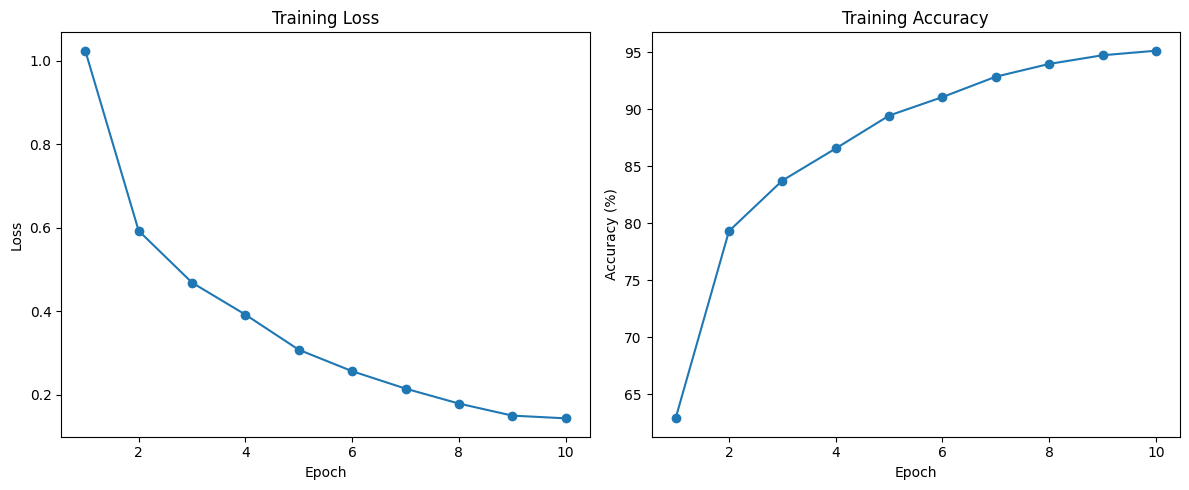

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

## Training Curve Analysis

The training loss steadily decreased across epochs while training accuracy consistently improved.

This indicates that the CNN successfully learned meaningful spatial features from the satellite images without unstable training behavior.

The accuracy curve begins to stabilize in later epochs, suggesting that the model is approaching convergence.

## Model Evaluation

The trained model is evaluated on the test dataset to measure classification accuracy and test loss.

In [8]:
model.eval()

correct = 0
total = 0
test_loss = 0.0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.2677
Test Accuracy: 91.57%


## Classification Report

Precision, recall, and F1-score are calculated for each land use category.

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = dataset.classes

print(classification_report(all_labels, all_preds, target_names=class_names))

                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.89      0.91       608
              Forest       0.99      0.88      0.93       596
HerbaceousVegetation       0.88      0.90      0.89       624
             Highway       0.91      0.87      0.89       513
          Industrial       0.94      0.96      0.95       471
             Pasture       0.84      0.95      0.89       414
       PermanentCrop       0.87      0.86      0.87       488
         Residential       0.96      0.98      0.97       611
               River       0.88      0.88      0.88       486
             SeaLake       0.93      0.99      0.96       589

            accuracy                           0.92      5400
           macro avg       0.91      0.92      0.91      5400
        weighted avg       0.92      0.92      0.92      5400



## Confusion Matrix

The confusion matrix visualizes how well the model predicts each class and highlights classification errors between categories.

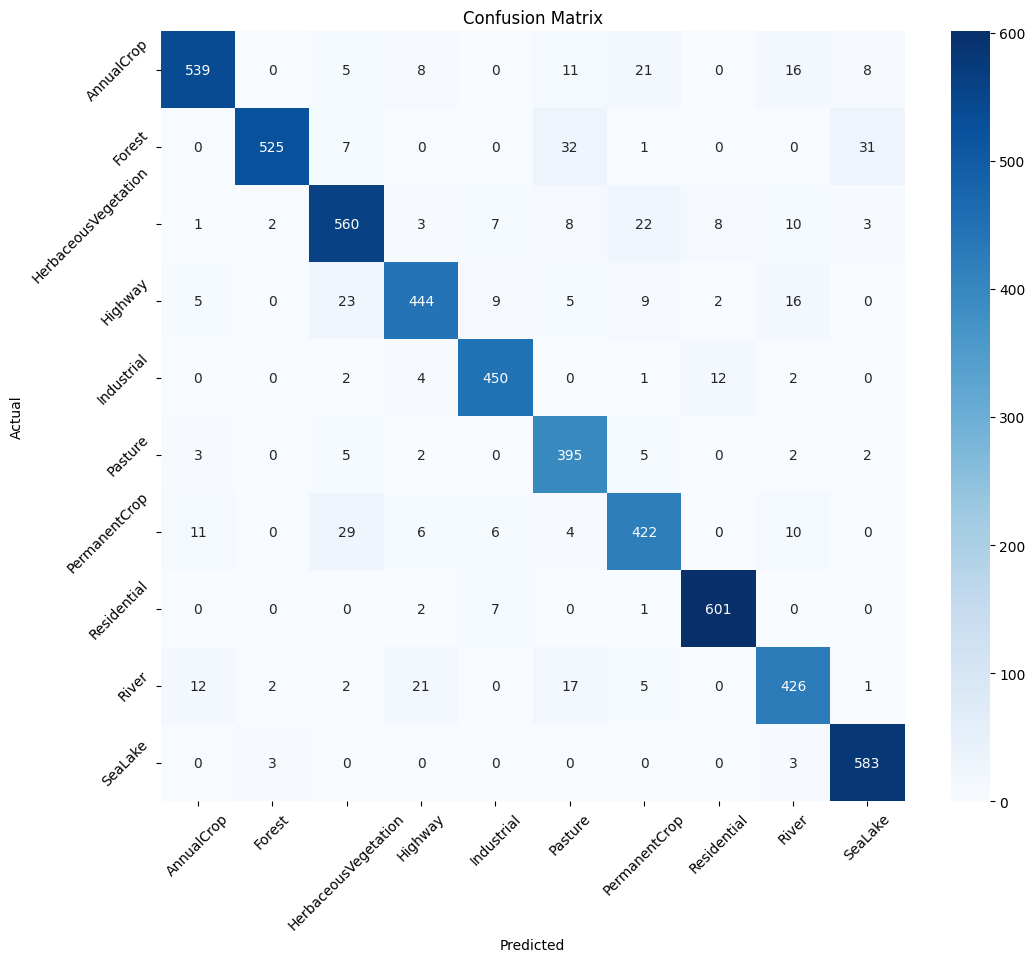

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.show()

## Confusion Matrix Analysis

The confusion matrix shows that the model performs strongly across most land use classes.

Classes such as Residential, Industrial, and SeaLake achieved high prediction accuracy with minimal misclassification.

Some confusion exists between visually similar categories such as:

- Highway and River
- PermanentCrop and HerbaceousVegetation
- AnnualCrop and Pasture

These misclassifications are expected because satellite images from these categories can contain overlapping spatial and texture patterns.

## Sample Predictions

Random test images are displayed along with their predicted and actual class labels.

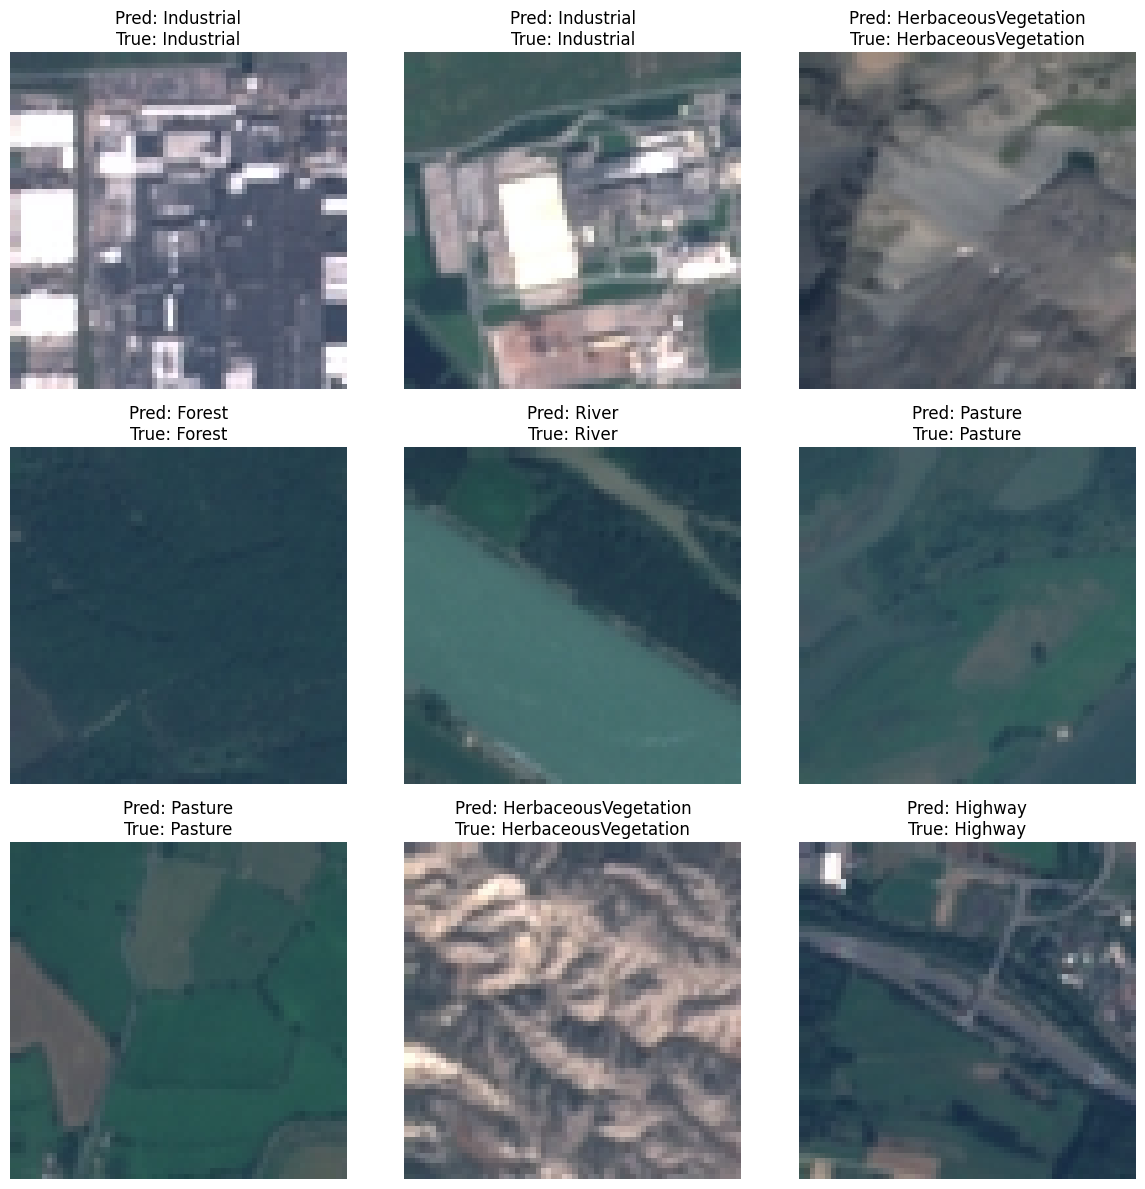

In [17]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()

    img = std * img + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)

    pred_label = class_names[preds[i]]
    true_label = class_names[labels[i]]

    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}")

    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
torch.save(model.state_dict(), "satellite_cnn_model.pth")

print("Model saved successfully.")

Model saved successfully.


## Conclusion

The CNN model achieved 91.57% test accuracy on the EuroSAT satellite image dataset.

The model performed strongly across most land use categories and demonstrated the effectiveness of CNNs for satellite image classification tasks.

This project demonstrates a complete deep learning workflow for computer vision using PyTorch and remote sensing data.

## Technologies Used

- Python
- PyTorch
- CNN (Convolutional Neural Networks)
- Computer Vision
- Remote Sensing
- Matplotlib
- Seaborn
- Scikit-learn